# Statistical Glossary

This notebook is a **comprehensive reference** of the statistical terminology used throughout this course. Every term is introduced with a **concrete example first**, followed by a **precise mathematical definition**. Terms are grouped by topic, roughly following the order in which they appear in the modules.

**How to use this notebook:**
- Read it once before starting the course to familiarise yourself with the language.
- Come back to it whenever you encounter a term you don't recognise.
- Each term includes the **module(s)** where it is used most heavily.

Many statistical terms have **synonyms** — different names for the same concept depending on the textbook, field, or tradition. These are noted explicitly so you're never confused when a paper says "explanatory variable" and your textbook says "predictor."

In [1]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system("pip install -q matplotlib numpy scipy")

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()

rng = np.random.default_rng(42)
print("Setup OK.")

Setup OK.


---

## 1. Probability Foundations

*Used heavily in Module 01; referenced everywhere.*

---

### Experiment, Outcome, Sample Space

**Example:** You roll a standard six-sided die. The *experiment* is the roll. Each face (1, 2, 3, 4, 5, 6) is an *outcome*. The set of all possible outcomes $\{1,2,3,4,5,6\}$ is the *sample space*.

**Definitions:**

| Term                                                 | Definition                                                                   |
|------------------------------------------------------|------------------------------------------------------------------------------|
| **Experiment** (syn. *trial*, *random experiment*)   | A process whose result is not known in advance.                              |
| **Outcome** (syn. *elementary event*, *realisation*) | A single possible result of an experiment.                                   |
| **Sample space** ($\Omega$)                          | The set of all possible outcomes: $\Omega = \{\omega_1, \omega_2, \ldots\}$. |

---

### Event

**Example:** "Rolling an even number" corresponds to the set $A = \{2, 4, 6\}$. This is an *event* — a subset of the sample space.

**Definition:** An **event** is any subset $A \subseteq \Omega$. We say event $A$ *occurs* if the observed outcome $\omega \in A$.

| Special event | Meaning                                            |
|---------------|----------------------------------------------------|
| $\Omega$      | The **certain event** — always occurs.             |
| $\varnothing$ | The **impossible event** — never occurs.           |
| $\{\omega\}$  | A **simple event** — contains exactly one outcome. |

---

### Probability

**Example:** If a fair die has 6 equally likely outcomes and 3 of them are even, the probability of rolling an even number is $P(\text{even}) = 3/6 = 0.5$.

**Definition:** A **probability** (syn. *probability measure*) is a function $P: \mathcal{F} \to [0,1]$ satisfying the **Kolmogorov axioms**:

1. $P(A) \geq 0$ for every event $A$.
2. $P(\Omega) = 1$.
3. For mutually exclusive events $A_1, A_2, \ldots$: $\;P\!\left(\bigcup_{i} A_i\right) = \sum_{i} P(A_i)$.

When all outcomes are equally likely: $P(A) = |A| / |\Omega|$ — this is **classical (Laplace) probability**.

---

### Conditional Probability

**Example:** You draw a card from a standard deck. Given that the card is red (26 out of 52), what is the probability it's a heart (13 out of 52)?

$$P(\text{heart} \mid \text{red}) = \frac{P(\text{heart} \cap \text{red})}{P(\text{red})} = \frac{13/52}{26/52} = \frac{1}{2}$$

**Definition:** The **conditional probability** of $A$ given $B$ (with $P(B)>0$) is:

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

The vertical bar "$\mid$" is read as "given" or "conditional on."

---

### Independence

**Example:** Flipping a coin twice — the result of the first flip doesn't affect the second. Getting heads on flip 1 and heads on flip 2 are *independent* events: $P(H_1 \cap H_2) = P(H_1) \cdot P(H_2) = 0.25$.

**Definition:** Events $A$ and $B$ are **independent** if:

$$P(A \cap B) = P(A) \cdot P(B)$$

Equivalently, $P(A \mid B) = P(A)$ — knowing $B$ occurred doesn't change the probability of $A$.

---

### Bayes' Theorem

**Example:** A medical test for a rare disease (prevalence 1%) has 95% sensitivity and 5% false-positive rate. You test positive — what's the probability you actually have the disease?

$$P(\text{disease} \mid +) = \frac{P(+ \mid \text{disease}) \cdot P(\text{disease})}{P(+)} = \frac{0.95 \times 0.01}{0.95 \times 0.01 + 0.05 \times 0.99} \approx 0.161$$

Only about 16%! The low *base rate* (prior) dominates.

**Definition:** **Bayes' theorem** relates conditional probabilities:

$$P(A \mid B) = \frac{P(B \mid A) \, P(A)}{P(B)}$$

Each component has a name (especially important in Bayesian statistics, Modules 07–09):

| Component     | Name                                                              | Role                                                |
|---------------|-------------------------------------------------------------------|-----------------------------------------------------|
| $P(A)$        | **Prior** (syn. *prior probability*, *base rate*)                 | Belief about $A$ before seeing evidence $B$.        |
| $P(B \mid A)$ | **Likelihood**                                                    | How probable the evidence is if $A$ is true.        |
| $P(A \mid B)$ | **Posterior** (syn. *posterior probability*)                      | Updated belief about $A$ after seeing evidence $B$. |
| $P(B)$        | **Marginal likelihood** (syn. *evidence*, *normalising constant*) | Total probability of observing $B$.                 |

---

### Law of Total Probability

**Example:** A factory has two machines. Machine A produces 60% of items (2% defective), Machine B produces 40% (5% defective). What fraction of all items is defective?

$$P(\text{defective}) = P(\text{def} \mid A)\,P(A) + P(\text{def} \mid B)\,P(B) = 0.02 \times 0.6 + 0.05 \times 0.4 = 0.032$$

**Definition:** If $B_1, B_2, \ldots, B_k$ form a **partition** of $\Omega$ (mutually exclusive, exhaustive), then for any event $A$:

$$P(A) = \sum_{i=1}^{k} P(A \mid B_i)\,P(B_i)$$

---

### Mutually Exclusive vs. Independent

These are commonly confused:

| Property                                 | Meaning                                                    | Can both hold?                           |
|------------------------------------------|------------------------------------------------------------|------------------------------------------|
| **Mutually exclusive** (syn. *disjoint*) | $A \cap B = \varnothing$ — they cannot both occur.         | Only if $P(A)=0$ or $P(B)=0$.            |
| **Independent**                          | $P(A \cap B) = P(A)\,P(B)$ — one doesn't affect the other. | Not if both have $P>0$ and are disjoint. |

If $A$ and $B$ are mutually exclusive with positive probabilities, knowing $A$ occurred tells you $B$ did *not* — so they are **dependent**.

---

## 2. Random Variables and Their Properties

*Introduced in Module 01; used everywhere from Module 02 onward.*

---

### Random Variable

**Example:** Roll a die and let $X$ be the number showing. $X$ can take values $1, 2, \ldots, 6$. Before you roll, $X$ is uncertain — it's a *random variable*.

**Definition:** A **random variable** (often abbreviated **RV**) is a function $X: \Omega \to \mathbb{R}$ that assigns a numerical value to each outcome in the sample space.

| Type              | Values                                          | Example                            |
|-------------------|-------------------------------------------------|------------------------------------|
| **Discrete RV**   | Countable set (finite or countably infinite)    | Number of heads in 10 flips        |
| **Continuous RV** | Any value in an interval (uncountably infinite) | Height of a randomly chosen person |

---

### PMF, PDF, CDF

These three functions fully describe a random variable's behaviour.

**Example (discrete):** For a fair die, the PMF assigns $P(X=k) = 1/6$ for each $k \in \{1,\ldots,6\}$.

**Example (continuous):** For a standard Normal, the PDF is the bell curve $f(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$.

| Function                             | Abbreviation | Applies to     | Definition                                                |
|--------------------------------------|--------------|----------------|-----------------------------------------------------------|
| **Probability mass function**        | PMF          | Discrete RVs   | $p(x) = P(X = x)$                                         |
| **Probability density function**     | PDF          | Continuous RVs | $f(x)$ such that $P(a \leq X \leq b) = \int_a^b f(x)\,dx$ |
| **Cumulative distribution function** | CDF          | Both           | $F(x) = P(X \leq x)$                                      |

Key properties:
- PMF: $\sum_x p(x) = 1$, each $p(x) \geq 0$.
- PDF: $\int_{-\infty}^{\infty} f(x)\,dx = 1$, each $f(x) \geq 0$. Note: $f(x)$ is **not** a probability — it can exceed 1.
- CDF: Non-decreasing, $F(-\infty) = 0$, $F(\infty) = 1$.

---

### Support

**Example:** A Poisson random variable takes values $0, 1, 2, \ldots$ — its support is $\mathbb{N}_0$. A Beta random variable lives on $(0, 1)$.

**Definition:** The **support** of a random variable is the set of values where its PMF or PDF is positive:

$$\text{supp}(X) = \{x : p(x) > 0\} \quad \text{or} \quad \{x : f(x) > 0\}$$

---

### Expected Value (Mean)

**Example:** A fair die: $E[X] = \frac{1}{6}(1+2+3+4+5+6) = 3.5$.

**Definition:** The **expected value** (syn. *mean*, *expectation*, *first moment*) is the probability-weighted average:

$$E[X] = \begin{cases} \sum_x x \cdot p(x) & \text{discrete} \\ \int_{-\infty}^{\infty} x \cdot f(x)\,dx & \text{continuous} \end{cases}$$

Common notation: $E[X]$, $\mu$, $\mu_X$.

**Linearity of expectation:** $E[aX + bY] = a\,E[X] + b\,E[Y]$ — this holds even if $X$ and $Y$ are dependent.

---

### Variance and Standard Deviation

**Example:** A fair die has $E[X] = 3.5$ and $E[X^2] = \frac{1}{6}(1+4+9+16+25+36) = 15.167$, so $\text{Var}(X) = 15.167 - 3.5^2 = 2.917$ and $\text{SD}(X) = \sqrt{2.917} \approx 1.71$.

**Definitions:**

$$\text{Var}(X) = E\!\left[(X - \mu)^2\right] = E[X^2] - (E[X])^2$$

$$\text{SD}(X) = \sigma = \sqrt{\text{Var}(X)}$$

| Term                   | Synonym(s)                  | What it measures                         |
|------------------------|-----------------------------|------------------------------------------|
| **Variance**           | $\text{Var}(X)$, $\sigma^2$ | Average squared deviation from the mean. |
| **Standard deviation** | SD, $\sigma$                | Spread in the same units as $X$.         |

Properties: $\text{Var}(aX + b) = a^2\,\text{Var}(X)$. If $X, Y$ are independent: $\text{Var}(X+Y) = \text{Var}(X) + \text{Var}(Y)$.

---

### Covariance and Correlation

**Example:** If taller people tend to weigh more, height and weight have *positive covariance*. If we standardise to a unitless measure, we get the *correlation*.

**Definitions:**

$$\text{Cov}(X, Y) = E\!\left[(X - \mu_X)(Y - \mu_Y)\right] = E[XY] - E[X]\,E[Y]$$

$$\text{Cor}(X, Y) = \rho_{XY} = \frac{\text{Cov}(X,Y)}{\sigma_X \, \sigma_Y}$$

| Term                                         | Range               | Interpretation                                                 |
|----------------------------------------------|---------------------|----------------------------------------------------------------|
| **Covariance**                               | $(-\infty, \infty)$ | Direction of linear relationship; units depend on $X$ and $Y$. |
| **Correlation** (syn. *Pearson correlation*) | $[-1, 1]$           | Strength and direction of **linear** relationship; unitless.   |

$\rho = 0$ means no **linear** relationship (but there may still be a nonlinear one). $|\rho| = 1$ means a perfect linear relationship.

---

### Moments

**Example:** The mean is the first moment. The variance uses the second central moment.

**Definition:** The **$k$-th raw moment** is $E[X^k]$. The **$k$-th central moment** is $E[(X - \mu)^k]$.

| Moment                     | $k$ | Name                                         |
|----------------------------|-----|----------------------------------------------|
| 1st raw                    | 1   | **Mean** ($\mu$)                             |
| 2nd central                | 2   | **Variance** ($\sigma^2$)                    |
| 3rd central (standardised) | 3   | **Skewness** — asymmetry of the distribution |
| 4th central (standardised) | 4   | **Kurtosis** — tail heaviness                |

The following plot illustrates PMF, PDF, and CDF side by side — a discrete Binomial on the left and a continuous Normal on the right.

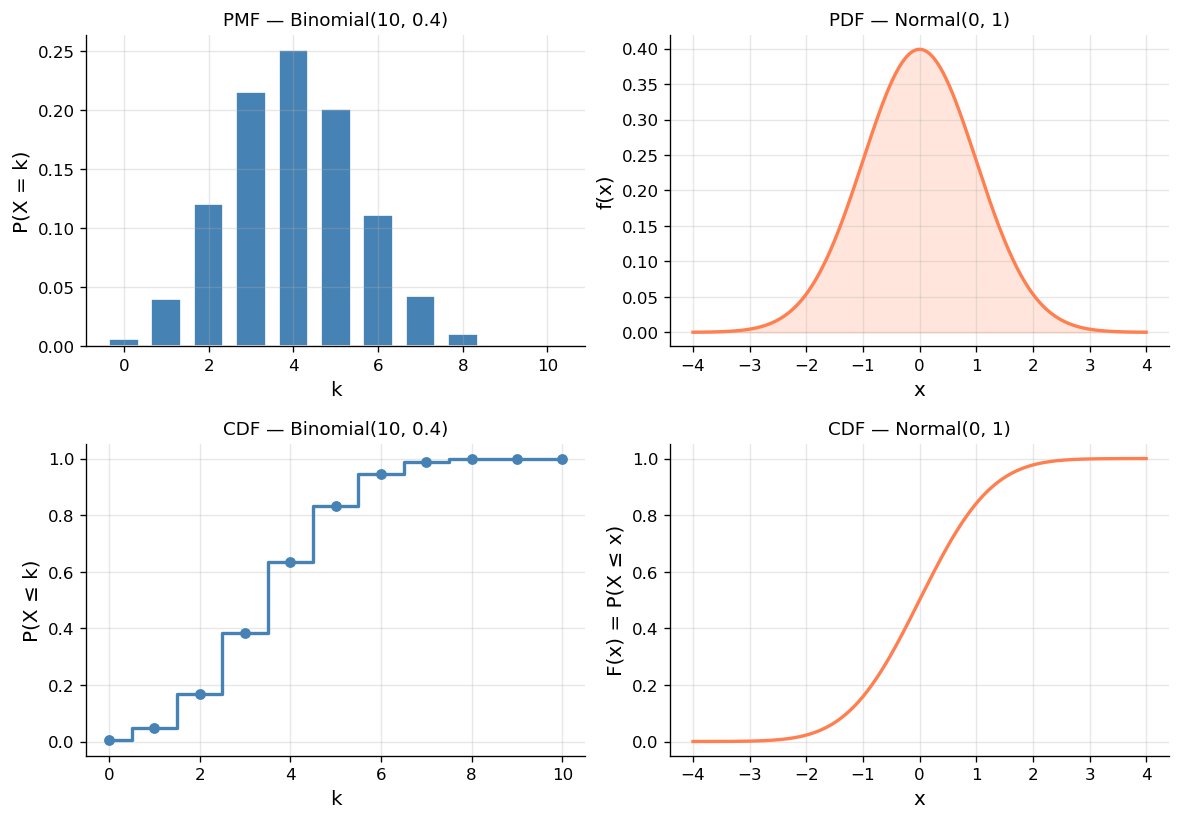

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# --- Left column: Discrete (Binomial n=10, p=0.4) ---
n_binom, p_binom = 10, 0.4
k = np.arange(0, n_binom + 1)
pmf_vals = stats.binom.pmf(k, n_binom, p_binom)
cdf_disc = stats.binom.cdf(k, n_binom, p_binom)

axes[0, 0].bar(k, pmf_vals, color="steelblue", edgecolor="white", width=0.7)
axes[0, 0].set_title("PMF — Binomial(10, 0.4)", fontsize=11)
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel("P(X = k)")

axes[1, 0].step(k, cdf_disc, where="mid", color="steelblue", linewidth=2)
axes[1, 0].scatter(k, cdf_disc, color="steelblue", zorder=5, s=30)
axes[1, 0].set_title("CDF — Binomial(10, 0.4)", fontsize=11)
axes[1, 0].set_xlabel("k")
axes[1, 0].set_ylabel("P(X ≤ k)")
axes[1, 0].set_ylim(-0.05, 1.05)

# --- Right column: Continuous (Normal μ=0, σ=1) ---
x = np.linspace(-4, 4, 300)
pdf_vals = stats.norm.pdf(x)
cdf_vals = stats.norm.cdf(x)

axes[0, 1].plot(x, pdf_vals, color="coral", linewidth=2)
axes[0, 1].fill_between(x, pdf_vals, alpha=0.2, color="coral")
axes[0, 1].set_title("PDF — Normal(0, 1)", fontsize=11)
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("f(x)")

axes[1, 1].plot(x, cdf_vals, color="coral", linewidth=2)
axes[1, 1].set_title("CDF — Normal(0, 1)", fontsize=11)
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("F(x) = P(X ≤ x)")
axes[1, 1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

---

## 3. Named Distributions

*Module 02 covers these in depth. They appear throughout the entire course.*

A **distribution** (syn. *probability distribution*) is a complete description of a random variable's probabilistic behaviour. A **parametric distribution** is a family of distributions indexed by one or more **parameters** — numbers that control the shape, location, or scale.

The following table is a quick-reference map. Detailed definitions and examples follow.

### 3.1 Discrete Distributions

| Distribution          | Notation               | Parameters                        | Support            | Mean       | Variance     | Typical use                            |
|-----------------------|------------------------|-----------------------------------|--------------------|------------|--------------|----------------------------------------|
| **Bernoulli**         | $\text{Bernoulli}(p)$  | $p \in [0,1]$                     | $\{0, 1\}$         | $p$        | $p(1-p)$     | Single yes/no trial                    |
| **Binomial**          | $\text{Bin}(n, p)$     | $n \in \mathbb{N}$, $p \in [0,1]$ | $\{0,\ldots,n\}$   | $np$       | $np(1-p)$    | Count of successes in $n$ trials       |
| **Poisson**           | $\text{Pois}(\lambda)$ | $\lambda > 0$                     | $\mathbb{N}_0$     | $\lambda$  | $\lambda$    | Count of rare events in fixed interval |
| **Geometric**         | $\text{Geom}(p)$       | $p \in (0,1]$                     | $\{1, 2, \ldots\}$ | $1/p$      | $(1-p)/p^2$  | Number of trials until first success   |
| **Negative Binomial** | $\text{NegBin}(r, p)$  | $r > 0$, $p \in (0,1]$            | $\mathbb{N}_0$     | $r(1-p)/p$ | $r(1-p)/p^2$ | Trials until $r$-th success            |

**Key relationships:**
- Bernoulli is Binomial with $n=1$.
- Geometric is Negative Binomial with $r=1$.
- As $n \to \infty$ and $p \to 0$ with $np = \lambda$, Binomial $\to$ Poisson (the **Poisson limit theorem** or **law of rare events**).

### 3.2 Continuous Distributions

| Distribution         | Notation                      | Parameters                              | Support       | Mean                             | Variance                                               |
|----------------------|-------------------------------|-----------------------------------------|---------------|----------------------------------|--------------------------------------------------------|
| **Uniform**          | $\text{Unif}(a, b)$           | $a < b$                                 | $[a, b]$      | $(a+b)/2$                        | $(b-a)^2/12$                                           |
| **Normal**           | $N(\mu, \sigma^2)$            | $\mu \in \mathbb{R}$, $\sigma > 0$      | $\mathbb{R}$  | $\mu$                            | $\sigma^2$                                             |
| **Exponential**      | $\text{Exp}(\lambda)$         | $\lambda > 0$                           | $[0, \infty)$ | $1/\lambda$                      | $1/\lambda^2$                                          |
| **Gamma**            | $\text{Gamma}(\alpha, \beta)$ | $\alpha, \beta > 0$                     | $(0, \infty)$ | $\alpha/\beta$                   | $\alpha/\beta^2$                                       |
| **Beta**             | $\text{Beta}(\alpha, \beta)$  | $\alpha, \beta > 0$                     | $(0, 1)$      | $\frac{\alpha}{\alpha+\beta}$    | $\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$ |
| **Chi-squared**      | $\chi^2(k)$                   | $k \in \mathbb{N}$ (degrees of freedom) | $(0, \infty)$ | $k$                              | $2k$                                                   |
| **Student's $t$**    | $t(\nu)$                      | $\nu > 0$ (degrees of freedom)          | $\mathbb{R}$  | $0$ (if $\nu>1$)                 | $\frac{\nu}{\nu-2}$ (if $\nu>2$)                       |
| **$F$-distribution** | $F(d_1, d_2)$                 | $d_1, d_2 > 0$                          | $(0, \infty)$ | $\frac{d_2}{d_2-2}$ (if $d_2>2$) | —                                                      |

**Key relationships:**
- Exponential is Gamma with $\alpha = 1$.
- Chi-squared is Gamma with $\alpha = k/2$, $\beta = 1/2$.
- The $t$-distribution approaches the Normal as $\nu \to \infty$.
- If $Z \sim N(0,1)$, then $Z^2 \sim \chi^2(1)$.

### Important distribution concepts

| Term                                           | Definition                                                                                                               |
|------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------|
| **Parameter**                                  | A constant that indexes a distribution family (e.g., $\mu$, $\sigma$, $p$, $\lambda$).                                   |
| **Location parameter**                         | Shifts the distribution left/right (e.g., $\mu$ in Normal).                                                              |
| **Scale parameter**                            | Stretches/compresses the distribution (e.g., $\sigma$ in Normal).                                                        |
| **Shape parameter**                            | Changes the distribution's form (e.g., $\alpha$ in Gamma).                                                               |
| **Rate parameter**                             | Inverse of scale (e.g., $\lambda$ in Exponential: rate = $\lambda$, scale = $1/\lambda$).                                |
| **Degrees of freedom** (syn. *df*, $\nu$, $k$) | Parameter controlling shape of $t$, $\chi^2$, and $F$ distributions; typically related to sample size minus constraints. |

The following plot shows several of the key distributions so you can recognise their shapes.

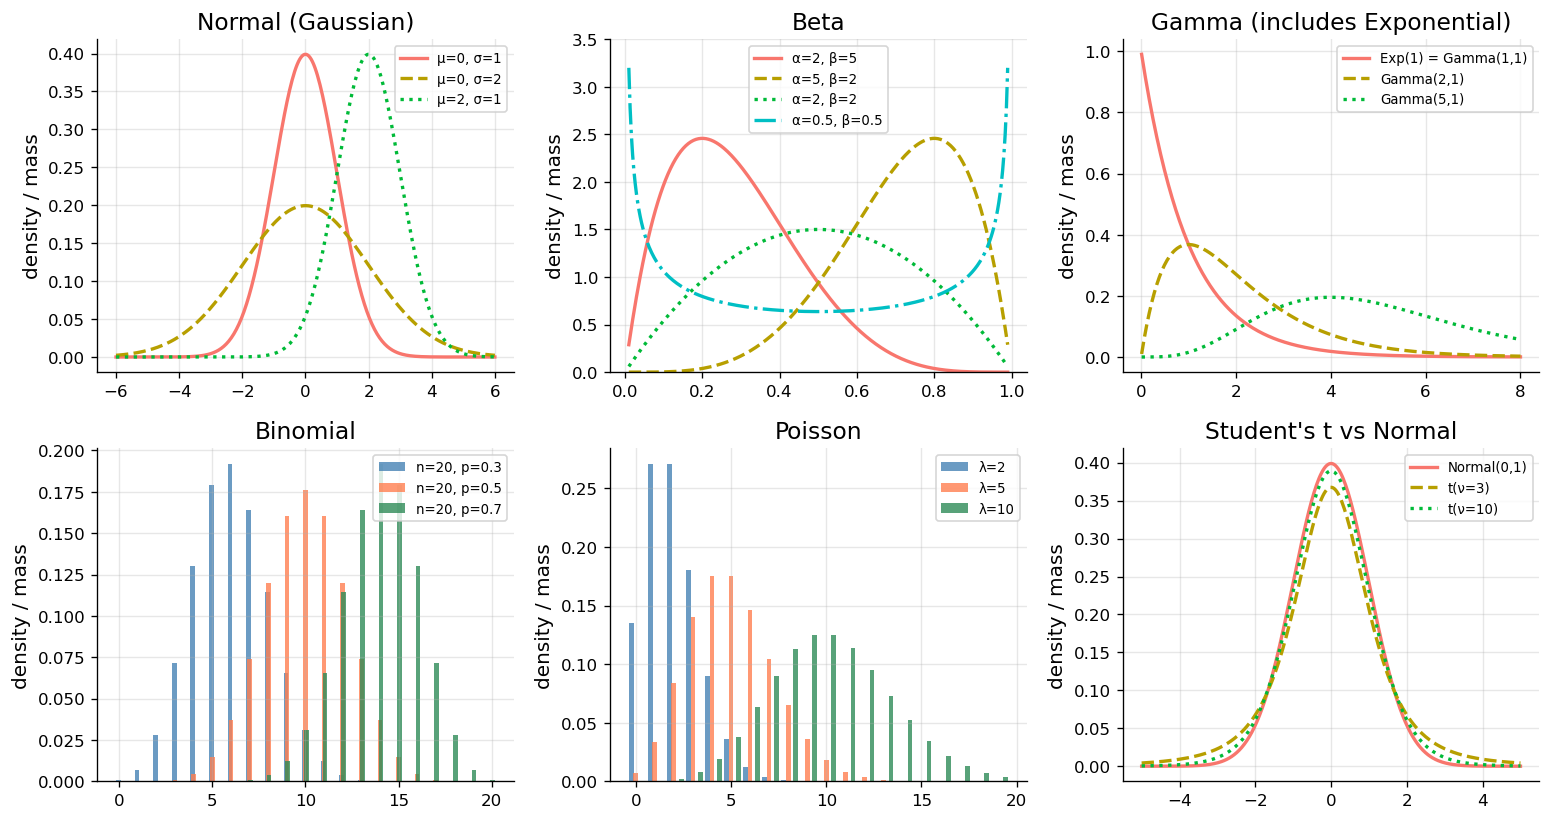

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

# Normal variations
x = np.linspace(-6, 6, 300)
for mu, sigma, ls in [(0, 1, "-"), (0, 2, "--"), (2, 1, ":")]:
    axes[0, 0].plot(
        x,
        stats.norm.pdf(x, mu, sigma),
        label=f"μ={mu}, σ={sigma}",
        linewidth=2,
        linestyle=ls,
    )
axes[0, 0].set_title("Normal (Gaussian)")
axes[0, 0].legend(fontsize=8)

# Beta variations
x01 = np.linspace(0.01, 0.99, 300)
for a, b, ls in [(2, 5, "-"), (5, 2, "--"), (2, 2, ":"), (0.5, 0.5, "-.")]:
    axes[0, 1].plot(
        x01, stats.beta.pdf(x01, a, b), label=f"α={a}, β={b}", linewidth=2, linestyle=ls
    )
axes[0, 1].set_title("Beta")
axes[0, 1].legend(fontsize=8)
axes[0, 1].set_ylim(0, 3.5)

# Exponential / Gamma
xp = np.linspace(0.01, 8, 300)
for a, ls, lbl in [
    (1, "-", "Exp(1) = Gamma(1,1)"),
    (2, "--", "Gamma(2,1)"),
    (5, ":", "Gamma(5,1)"),
]:
    axes[0, 2].plot(xp, stats.gamma.pdf(xp, a), label=lbl, linewidth=2, linestyle=ls)
axes[0, 2].set_title("Gamma (includes Exponential)")
axes[0, 2].legend(fontsize=8)

# Binomial
k10 = np.arange(0, 21)
for n, p, c in [(20, 0.3, "steelblue"), (20, 0.5, "coral"), (20, 0.7, "seagreen")]:
    axes[1, 0].bar(
        k10 + (p - 0.5) * 0.25,
        stats.binom.pmf(k10, n, p),
        width=0.25,
        alpha=0.8,
        label=f"n={n}, p={p}",
        color=c,
    )
axes[1, 0].set_title("Binomial")
axes[1, 0].legend(fontsize=8)

# Poisson
kp = np.arange(0, 20)
for lam, c in [(2, "steelblue"), (5, "coral"), (10, "seagreen")]:
    axes[1, 1].bar(
        kp + (lam - 5) * 0.08,
        stats.poisson.pmf(kp, lam),
        width=0.25,
        alpha=0.8,
        label=f"λ={lam}",
        color=c,
    )
axes[1, 1].set_title("Poisson")
axes[1, 1].legend(fontsize=8)

# Student's t vs Normal
xt = np.linspace(-5, 5, 300)
axes[1, 2].plot(xt, stats.norm.pdf(xt), label="Normal(0,1)", linewidth=2)
for nu, ls in [(3, "--"), (10, ":")]:
    axes[1, 2].plot(
        xt, stats.t.pdf(xt, nu), label=f"t(ν={nu})", linewidth=2, linestyle=ls
    )
axes[1, 2].set_title("Student's t vs Normal")
axes[1, 2].legend(fontsize=8)

for ax in axes.flat:
    ax.set_ylabel("density / mass")
plt.tight_layout()
plt.show()

---

## 4. Convergence Theorems and Inequalities

*Module 01 (inequalities notebook); referenced in Modules 02–04.*

---

### Law of Large Numbers (LLN)

**Example:** Flip a fair coin many times. After 10 flips the fraction of heads might be 0.7; after 10,000 flips it will be very close to 0.5.

**Definition:** The **weak law of large numbers** states that for i.i.d. random variables $X_1, X_2, \ldots$ with mean $\mu$:

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{P} \mu \quad \text{as } n \to \infty$$

The sample mean *converges in probability* to the true mean. (The **strong LLN** gives almost-sure convergence.)

| Term                                                        | Definition                                                                                          |
|-------------------------------------------------------------|-----------------------------------------------------------------------------------------------------|
| **i.i.d.** (syn. *independent and identically distributed*) | Random variables that are mutually independent and all share the same distribution.                 |
| **Convergence in probability**                              | $X_n \xrightarrow{P} c$ means $P(\lvert X_n - c \rvert > \epsilon) \to 0$ for every $\epsilon > 0$. |

---

### Central Limit Theorem (CLT)

**Example:** Roll a die 100 times and compute the average. Repeat this experiment many times — the distribution of those averages will look Normal, even though a single die roll is Uniform.

**Definition:** For i.i.d. $X_1, \ldots, X_n$ with mean $\mu$ and variance $\sigma^2$, as $n \to \infty$:

$$\frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} \xrightarrow{d} N(0, 1)$$

The CLT is **why the Normal distribution is everywhere** — any average of many independent contributions tends to be approximately Normal, regardless of the underlying distribution.

| Term                                 | Definition                                                                                                              |
|--------------------------------------|-------------------------------------------------------------------------------------------------------------------------|
| **Convergence in distribution**      | $X_n \xrightarrow{d} X$ means the CDF of $X_n$ converges to the CDF of $X$ at all continuity points.                    |
| **Standard error** (syn. SE)         | The standard deviation of a statistic's sampling distribution; for $\bar{X}$: $\text{SE}(\bar{X}) = \sigma / \sqrt{n}$. |
| **Standardisation** (syn. *z-score*) | Transform $X$ to $Z = (X - \mu)/\sigma$ so that $Z$ has mean 0 and variance 1.                                          |

---

### Key Inequalities

| Inequality         | Statement                                          | Use                                        |
|--------------------|----------------------------------------------------|--------------------------------------------|
| **Markov**         | $P(X \geq a) \leq E[X]/a$ for $X \geq 0$           | Loose upper bound on tail probability.     |
| **Chebyshev**      | $P(\lvert X - \mu \rvert \geq k\sigma) \leq 1/k^2$ | Tighter tail bound using variance.         |
| **Cauchy–Schwarz** | $\lvert E[XY] \rvert \leq \sqrt{E[X^2]\,E[Y^2]}$   | Proves that $\lvert\rho\rvert \leq 1$.     |
| **Jensen**         | $E[g(X)] \geq g(E[X])$ for convex $g$              | Used in information theory and MLE proofs. |

---

## 5. Descriptive Statistics

*Module 03; used whenever we explore data.*

**Descriptive statistics** summarise a dataset's main features. They split into **measures of central tendency** (where is the data?) and **measures of spread** (how spread out is it?).

---

### Population vs. Sample

This distinction is fundamental and appears everywhere.

**Example:** You want to know the average height of all adults in a country (population). You measure 500 people (sample) and compute their average.

| Term                     | Synonym(s)  | Definition                                                                    |
|--------------------------|-------------|-------------------------------------------------------------------------------|
| **Population**           | *universe*  | The complete set of all units of interest.                                    |
| **Sample**               | —           | A subset of the population that we actually observe.                          |
| **Population parameter** | —           | A fixed (unknown) quantity describing the population (e.g., $\mu$, $\sigma$). |
| **Sample statistic**     | *statistic* | A quantity computed from the sample (e.g., $\bar{X}$, $S$).                   |
| **Census**               | —           | Observing the entire population (usually impractical).                        |

The goal of **statistical inference** is to learn about population parameters using sample statistics.

---

### Measures of Central Tendency

| Statistic                   | Formula                          | Robust?                    | When to use                                |
|-----------------------------|----------------------------------|----------------------------|--------------------------------------------|
| **Sample mean** ($\bar{X}$) | $\frac{1}{n}\sum_{i=1}^n X_i$    | No — sensitive to outliers | Symmetric data, no extreme outliers        |
| **Median**                  | Middle value when data is sorted | Yes                        | Skewed data or outliers present            |
| **Mode**                    | Most frequently occurring value  | Yes                        | Categorical data; multimodal distributions |

---

### Measures of Spread

| Statistic                           | Formula                                       | Notes                                                |
|-------------------------------------|-----------------------------------------------|------------------------------------------------------|
| **Range**                           | $X_{\max} - X_{\min}$                         | Simple but sensitive to outliers.                    |
| **Sample variance** ($S^2$)         | $\frac{1}{n-1}\sum_{i=1}^n (X_i - \bar{X})^2$ | Divides by $n-1$, not $n$ (**Bessel's correction**). |
| **Sample standard deviation** ($S$) | $\sqrt{S^2}$                                  | In same units as the data.                           |
| **Interquartile range** (IQR)       | $Q_3 - Q_1$                                   | Robust measure of spread.                            |

| Term                                         | Definition                                                                                                                           |
|----------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------|
| **Bessel's correction**                      | Dividing by $n-1$ instead of $n$ when computing sample variance, making $S^2$ an **unbiased** estimator of $\sigma^2$.               |
| **Quantile** (syn. *percentile*, *quartile*) | Value below which a given fraction of the data falls. $Q_1$ = 25th percentile, $Q_2$ = median, $Q_3$ = 75th percentile.              |
| **Outlier**                                  | An observation far from the bulk of the data; often defined as outside $[Q_1 - 1.5 \cdot \text{IQR},\; Q_3 + 1.5 \cdot \text{IQR}]$. |

---

### Common Plots for Descriptive Statistics

| Plot                                       | What it shows                                                                                               |
|--------------------------------------------|-------------------------------------------------------------------------------------------------------------|
| **Histogram**                              | Frequency distribution of a single variable; approximates the PDF/PMF.                                      |
| **Box plot** (syn. *box-and-whisker plot*) | Median, quartiles, range, and outliers at a glance.                                                         |
| **Scatter plot**                           | Relationship between two continuous variables.                                                              |
| **Q-Q plot** (quantile-quantile)           | Compares sample quantiles to theoretical quantiles (usually Normal) — points on the diagonal mean good fit. |
| **Violin plot**                            | Like a box plot but shows the full density shape.                                                           |

---

### Skewness and Kurtosis

**Example:** Income distributions are right-skewed (long right tail). A Normal distribution has zero skewness.

| Term                | Measures                          | Sign                                                                        |
|---------------------|-----------------------------------|-----------------------------------------------------------------------------|
| **Skewness**        | Asymmetry of the distribution     | Positive = right tail longer; Negative = left tail longer; Zero = symmetric |
| **Kurtosis**        | Tail heaviness relative to Normal | High kurtosis = heavy tails (more extreme values); Normal has kurtosis 3    |
| **Excess kurtosis** | Kurtosis $- 3$                    | Makes Normal the baseline at 0                                              |

The following plot shows how skewness and kurtosis affect a distribution's shape.

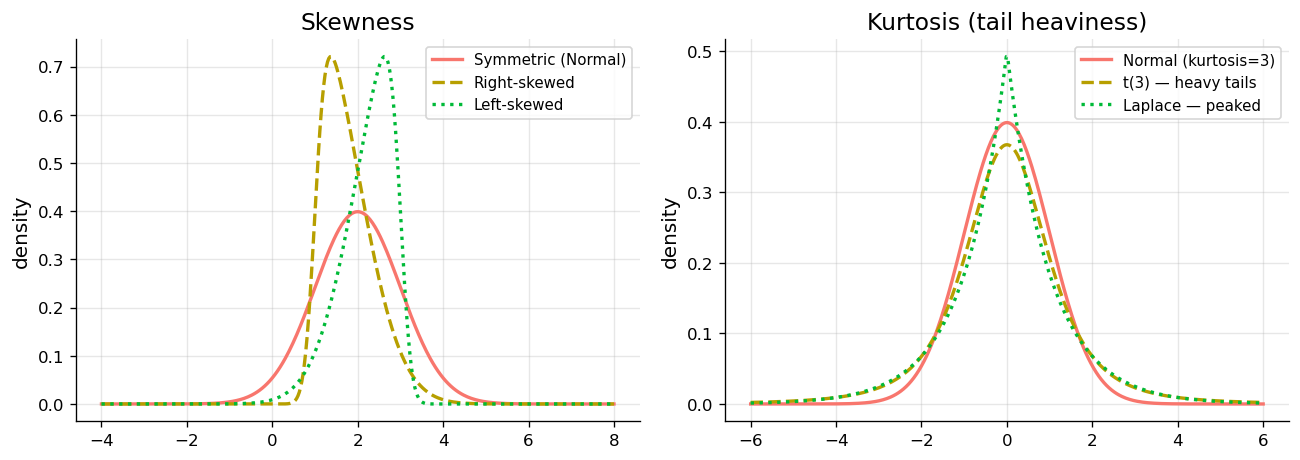

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

x = np.linspace(-4, 8, 400)

# Skewness comparison
axes[0].plot(x, stats.norm.pdf(x, 2, 1), label="Symmetric (Normal)", linewidth=2)
axes[0].plot(
    x,
    stats.skewnorm.pdf(x, 5, loc=1, scale=1),
    label="Right-skewed",
    linewidth=2,
    linestyle="--",
)
axes[0].plot(
    x,
    stats.skewnorm.pdf(x, -5, loc=3, scale=1),
    label="Left-skewed",
    linewidth=2,
    linestyle=":",
)
axes[0].set_title("Skewness")
axes[0].legend(fontsize=9)
axes[0].set_ylabel("density")

# Kurtosis comparison
x2 = np.linspace(-6, 6, 400)
axes[1].plot(x2, stats.norm.pdf(x2), label="Normal (kurtosis=3)", linewidth=2)
axes[1].plot(
    x2, stats.t.pdf(x2, 3), label="t(3) — heavy tails", linewidth=2, linestyle="--"
)
axes[1].plot(
    x2, stats.laplace.pdf(x2), label="Laplace — peaked", linewidth=2, linestyle=":"
)
axes[1].set_title("Kurtosis (tail heaviness)")
axes[1].legend(fontsize=9)
axes[1].set_ylabel("density")

plt.tight_layout()
plt.show()

---

## 6. Estimation

*Module 04; foundational for everything that follows.*

**Estimation** is the process of using sample data to guess (estimate) unknown population parameters.

---

### Estimator vs. Estimate

**Example:** The formula $\bar{X} = \frac{1}{n}\sum X_i$ is an *estimator* (a rule). If you collect data $\{3, 7, 5\}$ and compute $\bar{X} = 5$, then 5 is the *estimate* (a number).

| Term                             | What it is                                                  | Example                                     |
|----------------------------------|-------------------------------------------------------------|---------------------------------------------|
| **Estimator** (syn. *statistic*) | A **function** of the sample data — a random variable.      | $\hat{\mu} = \bar{X} = \frac{1}{n}\sum X_i$ |
| **Estimate**                     | A **specific value** obtained by plugging in observed data. | $\hat{\mu} = 5.0$                           |

Convention: $\hat{\theta}$ ("theta-hat") denotes an estimator of parameter $\theta$.

---

### Properties of Estimators

| Property                     | Definition                                                                                     | Why it matters                                      |
|------------------------------|------------------------------------------------------------------------------------------------|-----------------------------------------------------|
| **Bias**                     | $\text{Bias}(\hat\theta) = E[\hat\theta] - \theta$                                             | How far the estimator is from the truth on average. |
| **Unbiased**                 | $E[\hat\theta] = \theta$ (bias = 0)                                                            | On average, the estimator hits the target.          |
| **Consistency**              | $\hat\theta_n \xrightarrow{P} \theta$ as $n \to \infty$                                        | More data $\Rightarrow$ better estimates.           |
| **Efficiency**               | Lowest variance among all unbiased estimators                                                  | The most "precise" unbiased estimator.              |
| **Mean squared error (MSE)** | $\text{MSE}(\hat\theta) = E[(\hat\theta - \theta)^2] = \text{Bias}^2 + \text{Var}(\hat\theta)$ | Total error = bias² + variance.                     |

The **bias-variance tradeoff**: sometimes a slightly biased estimator has much lower variance, giving a smaller MSE overall.

---

### Sampling Distribution

**Example:** Imagine drawing 1,000 different samples of size $n=30$ from the same population, computing $\bar{X}$ each time. The distribution of those 1,000 means is the *sampling distribution* of $\bar{X}$.

**Definition:** The **sampling distribution** of a statistic is the probability distribution of that statistic over all possible samples of the same size from the same population.

Key insight: an estimator is a random variable (it varies across samples), not a fixed number.

---

### Maximum Likelihood Estimation (MLE)

**Example:** You flip a coin 100 times and get 63 heads. The MLE of $p$ is $\hat{p} = 63/100 = 0.63$ — the value of $p$ that makes the observed data most probable.

**Definition:** The **maximum likelihood estimator** (MLE) is the parameter value that maximises the likelihood function:

$$\hat\theta_{\text{MLE}} = \arg\max_\theta \; L(\theta) = \arg\max_\theta \prod_{i=1}^n f(x_i \mid \theta)$$

| Term                                | Definition                                                                                                                             |
|-------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------|
| **Likelihood function** $L(\theta)$ | The joint probability of the observed data, viewed as a function of $\theta$: $L(\theta) = \prod_{i=1}^n f(x_i \mid \theta)$.          |
| **Log-likelihood** $\ell(\theta)$   | $\ell(\theta) = \ln L(\theta) = \sum_{i=1}^n \ln f(x_i \mid \theta)$. Easier to work with (sums vs. products).                         |
| **Score function**                  | $s(\theta) = \frac{\partial \ell}{\partial \theta}$. Setting $s(\theta) = 0$ gives the MLE.                                            |
| **Fisher information** $I(\theta)$  | $I(\theta) = -E\!\left[\frac{\partial^2 \ell}{\partial \theta^2}\right]$. Measures how much information the data carry about $\theta$. |
| **Cramér-Rao lower bound**          | $\text{Var}(\hat\theta) \geq \frac{1}{n \cdot I(\theta)}$ for any unbiased estimator. The MLE achieves this asymptotically.            |

---

### Method of Moments

**Example:** For a Normal distribution, the first moment is $\mu$ and the second central moment is $\sigma^2$. Set them equal to the sample mean and variance to get $\hat\mu = \bar{X}$, $\hat\sigma^2 = S^2$.

**Definition:** The **method of moments** estimates parameters by equating population moments $E[X^k]$ to their sample counterparts $\frac{1}{n}\sum X_i^k$ and solving.

---

### Confidence Intervals

**Example:** "The 95% confidence interval for the population mean is $(4.2, 5.8)$." This means: if we repeated the experiment many times, 95% of such intervals would contain the true $\mu$.

**Definition:** A **$(1-\alpha)$ confidence interval** for parameter $\theta$ is a random interval $[L, U]$ (computed from the sample) such that:

$$P(L \leq \theta \leq U) = 1 - \alpha$$

| Term                   | Definition                                                                                               |
|------------------------|----------------------------------------------------------------------------------------------------------|
| **Confidence level**   | $1 - \alpha$ (commonly 0.95 or 95%).                                                                     |
| **Significance level** | $\alpha$ (commonly 0.05).                                                                                |
| **Margin of error**    | Half the width of a symmetric CI: $z^* \times \text{SE}$ or $t^* \times \text{SE}$.                      |
| **Critical value**     | The $z^*$ or $t^*$ cutoff from the reference distribution corresponding to the desired confidence level. |

**Common misconception:** A 95% CI does **not** mean "there is a 95% probability that $\theta$ is in this interval." The interval is random, $\theta$ is fixed. The 95% refers to the long-run coverage rate of the *procedure*.

---

## 7. Hypothesis Testing

*Module 05; used in Modules 06, 08, and beyond.*

---

### The Testing Framework

**Example:** A pharmaceutical company claims their drug lowers blood pressure by 10 mmHg. You run a trial on 50 patients and observe a mean reduction of 7 mmHg. Is the difference from 10 due to random variation, or is the company's claim wrong?

| Term                                          | Synonym(s)                    | Definition                                                                                                                       |
|-----------------------------------------------|-------------------------------|----------------------------------------------------------------------------------------------------------------------------------|
| **Null hypothesis** ($H_0$)                   | —                             | The default claim, typically "no effect" or "no difference." E.g., $H_0: \mu = 10$.                                              |
| **Alternative hypothesis** ($H_1$ or $H_a$)   | *research hypothesis*         | What we suspect instead. E.g., $H_1: \mu \neq 10$ (two-sided) or $H_1: \mu < 10$ (one-sided).                                    |
| **Test statistic**                            | —                             | A summary of the data with a known distribution under $H_0$. E.g., $t = \frac{\bar{X} - \mu_0}{S/\sqrt{n}}$.                     |
| **p-value**                                   | *observed significance level* | The probability of observing a test statistic as extreme as (or more extreme than) the observed one, **assuming $H_0$ is true**. |
| **Significance level** ($\alpha$)             | *size of the test*            | Pre-chosen threshold (commonly 0.05). Reject $H_0$ if p-value $\leq \alpha$.                                                     |
| **Rejection region** (syn. *critical region*) | —                             | The set of test statistic values leading to rejection of $H_0$.                                                                  |
| **Critical value**                            | —                             | The boundary of the rejection region.                                                                                            |

**Decision rule:** If $\text{p-value} \leq \alpha$, reject $H_0$. Otherwise, **fail to reject** $H_0$ (not "accept $H_0$" — absence of evidence is not evidence of absence).

---

### One-Sided vs. Two-Sided Tests

| Type                              | $H_1$                                      | Rejection region | When to use                                         |
|-----------------------------------|--------------------------------------------|------------------|-----------------------------------------------------|
| **Two-sided** (syn. *two-tailed*) | $\theta \neq \theta_0$                     | Both tails       | No prior expectation of direction.                  |
| **One-sided** (syn. *one-tailed*) | $\theta > \theta_0$ or $\theta < \theta_0$ | One tail         | Strong prior reason to expect a specific direction. |

---

### Errors and Power

|                          | $H_0$ true                        | $H_0$ false                        |
|--------------------------|-----------------------------------|------------------------------------|
| **Reject $H_0$**         | **Type I error** (false positive) | Correct decision                   |
| **Fail to reject $H_0$** | Correct decision                  | **Type II error** (false negative) |

| Term              | Synonym(s)                      | Definition                                                                                              |
|-------------------|---------------------------------|---------------------------------------------------------------------------------------------------------|
| **Type I error**  | *false positive*, *false alarm* | Rejecting $H_0$ when it is actually true. Probability = $\alpha$.                                       |
| **Type II error** | *false negative*, *miss*        | Failing to reject $H_0$ when it is actually false. Probability = $\beta$.                               |
| **Power**         | $1 - \beta$                     | Probability of correctly rejecting $H_0$ when it is false — the test's ability to detect a real effect. |
| **Sensitivity**   | *true positive rate*, *recall*  | Same as power in a detection/classification context.                                                    |
| **Specificity**   | *true negative rate*            | $1 - \alpha$ — probability of correctly not rejecting $H_0$ when it's true.                             |

Power depends on: sample size $n$, effect size, significance level $\alpha$, and variability $\sigma$.

---

### Common Tests

| Test                    | Use case                                                 | Test statistic                                  |
|-------------------------|----------------------------------------------------------|-------------------------------------------------|
| **$z$-test**            | Mean with known $\sigma$                                 | $z = \frac{\bar{X} - \mu_0}{\sigma/\sqrt{n}}$   |
| **One-sample $t$-test** | Mean with unknown $\sigma$                               | $t = \frac{\bar{X} - \mu_0}{S/\sqrt{n}}$        |
| **Two-sample $t$-test** | Compare two independent means                            | $t = \frac{\bar{X}_1 - \bar{X}_2}{\text{SE}}$   |
| **Paired $t$-test**     | Compare matched/paired observations                      | $t$-test on differences $D_i = X_{1i} - X_{2i}$ |
| **Welch's $t$-test**    | Two-sample without equal-variance assumption             | Adjusts df for unequal variances                |
| **$\chi^2$ test**       | Goodness-of-fit or independence of categorical variables | $\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$       |
| **$F$-test**            | Compare two variances; used in ANOVA                     | $F = S_1^2 / S_2^2$                             |

---

### Multiple Testing

**Example:** Test 20 hypotheses at $\alpha = 0.05$. Even if all are null, you expect $20 \times 0.05 = 1$ false positive by chance.

| Term                             | Definition                                                                                           |
|----------------------------------|------------------------------------------------------------------------------------------------------|
| **Multiple testing problem**     | The inflation of false positives when many tests are conducted simultaneously.                       |
| **Familywise error rate (FWER)** | Probability of making *at least one* Type I error across all tests.                                  |
| **Bonferroni correction**        | Divide $\alpha$ by the number of tests $m$: use $\alpha/m$ per test. Controls FWER but conservative. |
| **False discovery rate (FDR)**   | Expected proportion of false positives among all rejections. Less conservative than FWER control.    |
| **Benjamini-Hochberg procedure** | Controls FDR by ranking p-values and using an adjusted threshold.                                    |

---

### Effect Size

| Term                         | Definition                                                                                        |
|------------------------------|---------------------------------------------------------------------------------------------------|
| **Effect size**              | A standardised measure of the magnitude of an effect, independent of sample size.                 |
| **Cohen's $d$**              | $d = \frac{\bar{X}_1 - \bar{X}_2}{S_{\text{pooled}}}$ — difference in means divided by pooled SD. |
| **Practical significance**   | Whether an effect is large enough to matter in practice (vs. merely *statistically* significant). |
| **Statistical significance** | p-value $\leq \alpha$. Does not imply the effect is large or important.                           |

---

### ROC Curves and Classification Metrics

*Module 05 (ROC notebook); also Module 11.*

| Term                                               | Definition                                                                                           |
|----------------------------------------------------|------------------------------------------------------------------------------------------------------|
| **ROC curve** (receiver operating characteristic)  | Plot of sensitivity (true positive rate) vs. false positive rate at varying thresholds.              |
| **AUC** (area under the ROC curve)                 | Overall measure of discriminative ability: 0.5 = random, 1.0 = perfect.                              |
| **Threshold** (syn. *cutoff*, *decision boundary*) | The value above which a score is classified as positive.                                             |
| **Precision** (syn. *positive predictive value*)   | $\frac{\text{TP}}{\text{TP} + \text{FP}}$ — of all predicted positives, how many are truly positive. |
| **Recall** (syn. *sensitivity*, *TPR*)             | $\frac{\text{TP}}{\text{TP} + \text{FN}}$ — of all actual positives, how many did we catch.          |
| **$F_1$ score**                                    | Harmonic mean of precision and recall: $\frac{2 \cdot P \cdot R}{P + R}$.                            |

The plot below shows the anatomy of a two-sided hypothesis test: the null distribution, rejection regions, and the relationship between $\alpha$, the critical value, and the p-value.

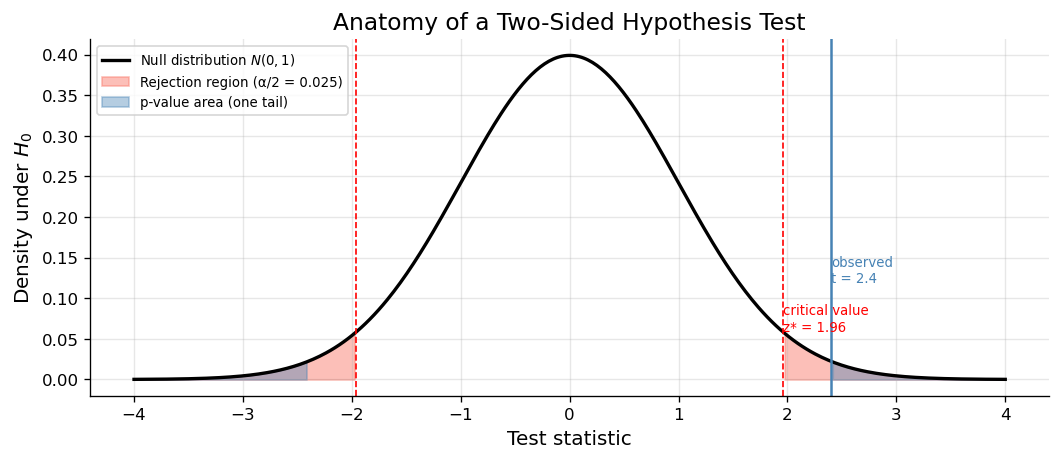

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

x = np.linspace(-4, 4, 400)
y = stats.norm.pdf(x)
alpha = 0.05
z_crit = stats.norm.ppf(1 - alpha / 2)  # ≈ 1.96
t_obs = 2.4  # example observed test statistic

ax.plot(x, y, "k-", linewidth=2, label="Null distribution $N(0,1)$")

# Rejection regions
ax.fill_between(
    x[x <= -z_crit],
    y[x <= -z_crit],
    color="salmon",
    alpha=0.5,
    label=f"Rejection region (α/2 = {alpha / 2})",
)
ax.fill_between(x[x >= z_crit], y[x >= z_crit], color="salmon", alpha=0.5)

# p-value shading
ax.fill_between(
    x[x >= t_obs],
    y[x >= t_obs],
    color="steelblue",
    alpha=0.4,
    label=f"p-value area (one tail)",
)
ax.fill_between(x[x <= -t_obs], y[x <= -t_obs], color="steelblue", alpha=0.4)

# Annotations
ax.axvline(z_crit, color="red", linestyle="--", linewidth=1)
ax.axvline(-z_crit, color="red", linestyle="--", linewidth=1)
ax.axvline(t_obs, color="steelblue", linestyle="-", linewidth=1.5)
ax.annotate(
    f"critical value\nz* = {z_crit:.2f}",
    xy=(z_crit, 0.06),
    fontsize=8,
    ha="left",
    color="red",
)
ax.annotate(
    f"observed\nt = {t_obs}", xy=(t_obs, 0.12), fontsize=8, ha="left", color="steelblue"
)

ax.set_xlabel("Test statistic")
ax.set_ylabel("Density under $H_0$")
ax.set_title("Anatomy of a Two-Sided Hypothesis Test")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

---

## 8. Linear Models and Regression

*Module 06; extended in Modules 08 (Bayesian regression) and 11 (regularisation).*

---

### Simple Linear Regression

**Example:** You have data on hours studied ($X$) and exam scores ($Y$) for 30 students. You fit a line $\hat{Y} = 45 + 5X$, meaning each extra hour of study is associated with 5 more points.

| Term                                          | Synonym(s)                                                                               | Definition                                       |
|-----------------------------------------------|------------------------------------------------------------------------------------------|--------------------------------------------------|
| **Response variable**                         | *dependent variable*, *outcome*, *target*, $Y$                                           | The variable we want to predict or explain.      |
| **Predictor**                                 | *independent variable*, *explanatory variable*, *covariate*, *feature*, *regressor*, $X$ | The variable(s) used to predict the response.    |
| **Intercept** ($\beta_0$)                     | *constant term*                                                                          | Expected value of $Y$ when all predictors are 0. |
| **Slope** ($\beta_1$)                         | *regression coefficient*                                                                 | Change in $E[Y]$ per one-unit increase in $X$.   |
| **Regression line** (syn. *line of best fit*) | —                                                                                        | $E[Y \mid X] = \beta_0 + \beta_1 X$.             |

---

### Ordinary Least Squares (OLS)

**Definition:** **OLS** finds the coefficients $\hat\beta_0, \hat\beta_1$ that minimise the sum of squared residuals:

$$\hat\beta = \arg\min_{\beta} \sum_{i=1}^n (Y_i - \beta_0 - \beta_1 X_i)^2$$

| Term                                                   | Definition                                                                                                 |
|--------------------------------------------------------|------------------------------------------------------------------------------------------------------------|
| **Fitted value** ($\hat{Y}_i$)                         | The model's prediction for observation $i$: $\hat{Y}_i = \hat\beta_0 + \hat\beta_1 X_i$.                   |
| **Residual** ($e_i$)                                   | Observed minus predicted: $e_i = Y_i - \hat{Y}_i$.                                                         |
| **Sum of squared residuals (SSR)** (syn. *RSS*, *SSE*) | $\sum e_i^2$ — what OLS minimises.                                                                         |
| **Total sum of squares (SST)**                         | $\sum (Y_i - \bar{Y})^2$ — total variation in $Y$.                                                         |
| **$R^2$** (syn. *coefficient of determination*)        | $R^2 = 1 - \text{SSR}/\text{SST}$ — proportion of variance in $Y$ explained by the model. Range: $[0, 1]$. |

---

### Multiple Regression

**Definition:** Extends simple regression to $p$ predictors: $E[Y \mid \mathbf{X}] = \beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p$.

| Term                                | Definition                                                                                                                                             |
|-------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Partial regression coefficient**  | $\beta_j$ measures the effect of $X_j$ on $Y$ *holding all other predictors constant*.                                                                 |
| **Adjusted $R^2$**                  | Penalises $R^2$ for the number of predictors; prevents artificial inflation from adding useless predictors.                                            |
| **Multicollinearity**               | High correlation among predictors — inflates standard errors, makes individual coefficients unreliable.                                                |
| **Variance inflation factor (VIF)** | Quantifies multicollinearity for predictor $X_j$: $\text{VIF}_j = \frac{1}{1 - R_j^2}$ where $R_j^2$ is from regressing $X_j$ on all other predictors. |

---

### Regression Diagnostics

| Term                       | What it checks                                 | How to check                                 |
|----------------------------|------------------------------------------------|----------------------------------------------|
| **Linearity**              | $E[Y \mid X]$ is linear in $X$                 | Residual vs. fitted plot — look for patterns |
| **Homoscedasticity**       | Constant variance of residuals                 | Residual vs. fitted — look for fanning       |
| **Heteroscedasticity**     | Non-constant variance (violation)              | Fan shape in residual plot                   |
| **Normality of residuals** | Residuals $\sim N(0, \sigma^2)$                | Q-Q plot, Shapiro-Wilk test                  |
| **Independence**           | Residuals uncorrelated                         | Residual vs. order plot, Durbin-Watson test  |
| **Leverage**               | How extreme an observation's $X$-values are    | Hat matrix diagonal $h_{ii}$                 |
| **Influential point**      | Observation that substantially changes the fit | Cook's distance                              |

---

### ANOVA (Analysis of Variance)

*Module 06 (ANOVA notebook).*

**Example:** Compare mean exam scores across three teaching methods. ANOVA tests whether at least one group mean differs from the others.

| Term                                                      | Synonym(s)                                   | Definition                                                                                                              |
|-----------------------------------------------------------|----------------------------------------------|-------------------------------------------------------------------------------------------------------------------------|
| **Factor**                                                | *grouping variable*, *categorical predictor* | The categorical variable defining groups.                                                                               |
| **Levels**                                                | *groups*, *categories*                       | The distinct values of the factor.                                                                                      |
| **Between-group variance** ($\text{MS}_{\text{between}}$) | —                                            | Variation of group means around the grand mean.                                                                         |
| **Within-group variance** ($\text{MS}_{\text{within}}$)   | *residual mean square*                       | Variation within each group.                                                                                            |
| **$F$-statistic**                                         | —                                            | $F = \text{MS}_{\text{between}} / \text{MS}_{\text{within}}$. Large $F$ $\Rightarrow$ evidence that group means differ. |
| **Grand mean**                                            | —                                            | Overall mean across all groups.                                                                                         |
| **Post-hoc test**                                         | —                                            | Follow-up pairwise comparisons after a significant ANOVA (e.g., Tukey's HSD).                                           |
| **Interaction**                                           | —                                            | When the effect of one factor depends on the level of another factor.                                                   |

---

### Model Selection

| Term                                     | Definition                                                                                       |
|------------------------------------------|--------------------------------------------------------------------------------------------------|
| **AIC** (Akaike information criterion)   | $\text{AIC} = -2\ell + 2p$ — balances fit and complexity. Lower is better.                       |
| **BIC** (Bayesian information criterion) | $\text{BIC} = -2\ell + p \ln n$ — stronger complexity penalty than AIC.                          |
| **Cross-validation**                     | Estimate out-of-sample performance by repeatedly splitting data into train/test sets.            |
| **Overfitting**                          | Model captures noise rather than signal — performs well on training data but poorly on new data. |
| **Underfitting**                         | Model is too simple — misses real patterns in the data.                                          |

The plot below illustrates OLS regression: the fitted line, residuals, and the decomposition $R^2 = 1 - \text{SSR}/\text{SST}$.

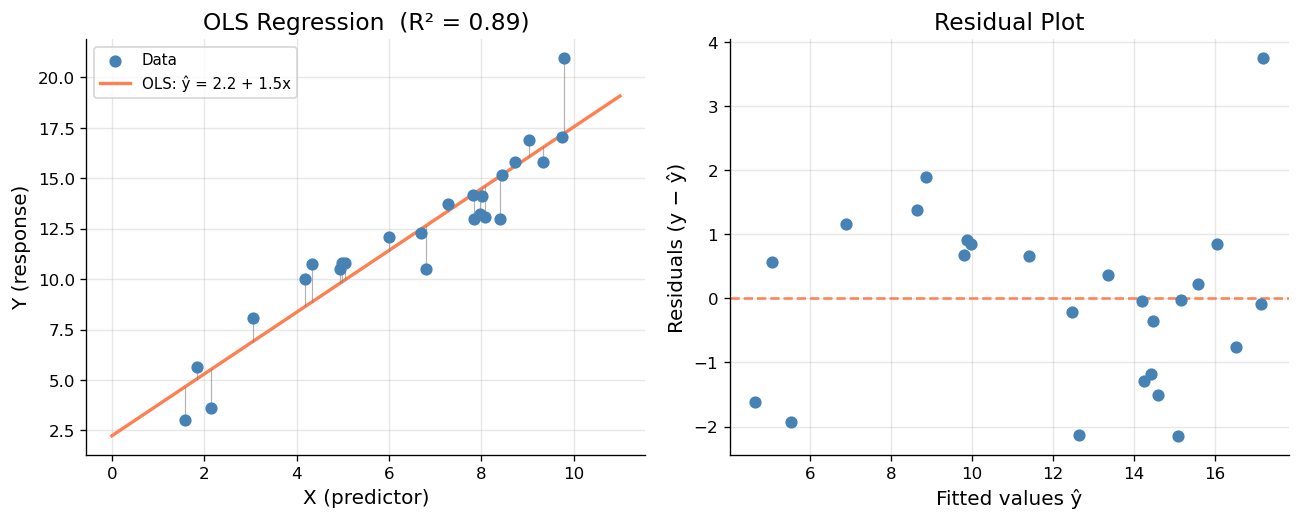

In [ ]:
np.random.seed(42)
x_data = rng.uniform(1, 10, 25)
y_data = 2 + 1.5 * x_data + rng.normal(0, 2, 25)

# OLS fit
slope, intercept, r_value, p_value, _ = stats.linregress(x_data, y_data)
y_hat = intercept + slope * x_data
residuals = y_data - y_hat

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: scatter + regression line + residuals
ax = axes[0]
ax.scatter(x_data, y_data, color="steelblue", s=40, zorder=3, label="Data")
x_line = np.linspace(0, 11, 100)
ax.plot(
    x_line,
    intercept + slope * x_line,
    "coral",
    linewidth=2,
    label=f"OLS: ŷ = {intercept:.1f} + {slope:.1f}x",
)
for xi, yi, yh in zip(x_data, y_data, y_hat):
    ax.plot([xi, xi], [yi, yh], color="gray", linewidth=0.7, alpha=0.6)
ax.set_xlabel("X (predictor)")
ax.set_ylabel("Y (response)")
ax.set_title(f"OLS Regression  (R² = {r_value**2:.2f})")
ax.legend(fontsize=9)

# Right: residual plot
ax2 = axes[1]
ax2.scatter(y_hat, residuals, color="steelblue", s=40, zorder=3)
ax2.axhline(0, color="coral", linestyle="--", linewidth=1.5)
ax2.set_xlabel("Fitted values ŷ")
ax2.set_ylabel("Residuals (y − ŷ)")
ax2.set_title("Residual Plot")

plt.tight_layout()
plt.show()

---

## 9. Bayesian Statistics

*Modules 07–09. The Bayesian framework is one of the two major paradigms of statistical inference (the other being frequentist).*

---

### Frequentist vs. Bayesian — The Two Paradigms

| Aspect                 | Frequentist                                          | Bayesian                                                         |
|------------------------|------------------------------------------------------|------------------------------------------------------------------|
| **Parameters**         | Fixed but unknown constants.                         | Random variables with distributions.                             |
| **Probability**        | Long-run frequency of events.                        | Degree of belief (can apply to one-time events).                 |
| **Inference**          | Based on sampling distributions and p-values.        | Based on posterior distributions.                                |
| **Prior information**  | Not formally incorporated.                           | Encoded in the prior distribution.                               |
| **Interval estimates** | Confidence interval (frequentist coverage property). | Credible interval (direct probability statement about $\theta$). |

---

### The Bayesian Workflow

$$\underbrace{P(\theta \mid \text{data})}_{\text{posterior}} = \frac{\overbrace{P(\text{data} \mid \theta)}^{\text{likelihood}} \;\times\; \overbrace{P(\theta)}^{\text{prior}}}{\underbrace{P(\text{data})}_{\text{marginal likelihood}}}$$

| Term                                                    | Synonym(s)                                           | Definition                                                                                     |
|---------------------------------------------------------|------------------------------------------------------|------------------------------------------------------------------------------------------------|
| **Prior distribution** $P(\theta)$                      | *prior*, *prior belief*                              | Your knowledge/belief about $\theta$ **before** seeing data.                                   |
| **Likelihood** $P(\text{data} \mid \theta)$             | —                                                    | How probable the observed data are for each possible $\theta$. (Same function as in MLE.)      |
| **Posterior distribution** $P(\theta \mid \text{data})$ | *posterior*, *updated belief*                        | Your knowledge about $\theta$ **after** incorporating the data.                                |
| **Marginal likelihood** $P(\text{data})$                | *evidence*, *normalising constant*, *model evidence* | $\int P(\text{data} \mid \theta)\,P(\theta)\,d\theta$ — ensures the posterior integrates to 1. |

---

### Types of Priors

| Prior type                                                                    | Definition                                                                                                     | Example                                                        |
|-------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------|
| **Informative prior**                                                         | Encodes substantial prior knowledge; concentrates probability in a narrow range.                               | $\theta \sim N(5, 0.5^2)$ from previous experiments.           |
| **Weakly informative prior** (syn. *regularising prior*)                      | Gently constrains $\theta$ to plausible values without dominating the data.                                    | $\theta \sim N(0, 10^2)$.                                      |
| **Non-informative prior** (syn. *flat prior*, *diffuse prior*, *vague prior*) | Assigns (approximately) equal probability to all values.                                                       | $\theta \sim \text{Unif}(-\infty, \infty)$ (improper).         |
| **Conjugate prior**                                                           | A prior whose posterior belongs to the same distributional family as the prior. Yields closed-form posteriors. | Beta prior + Binomial likelihood $\Rightarrow$ Beta posterior. |
| **Hyperparameter**                                                            | A parameter of the prior distribution (not of the data model).                                                 | $\alpha, \beta$ in $\theta \sim \text{Beta}(\alpha, \beta)$.   |

### Common Conjugate Pairs

| Likelihood              | Conjugate prior             | Posterior                                  |
|-------------------------|-----------------------------|--------------------------------------------|
| Binomial                | Beta$(\alpha, \beta)$       | Beta$(\alpha + k, \; \beta + n - k)$       |
| Poisson                 | Gamma$(\alpha, \beta)$      | Gamma$(\alpha + \sum x_i, \; \beta + n)$   |
| Normal (known $\sigma$) | Normal$(\mu_0, \sigma_0^2)$ | Normal (updated $\mu$, updated $\sigma^2$) |

---

### Posterior Summaries

| Term                                                                              | Definition                                                                                                                                                                       |
|-----------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Posterior mean**                                                                | $E[\theta \mid \text{data}]$ — point estimate from the posterior.                                                                                                                |
| **Posterior median**                                                              | Middle value of the posterior distribution.                                                                                                                                      |
| **MAP estimate** (maximum a posteriori)                                           | $\arg\max_\theta P(\theta \mid \text{data})$ — the mode of the posterior. Equivalent to MLE when the prior is flat.                                                              |
| **Credible interval** (syn. *Bayesian confidence interval*, *posterior interval*) | An interval $[a, b]$ such that $P(a \leq \theta \leq b \mid \text{data}) = 1 - \alpha$. Unlike confidence intervals, this **is** a direct probability statement about $\theta$.  |
| **Highest posterior density interval (HPDI)** (syn. *HDI*)                        | The narrowest credible interval for a given probability level.                                                                                                                   |
| **Posterior predictive distribution**                                             | Distribution of a **new** observation $\tilde{y}$ given the observed data: $P(\tilde{y} \mid \text{data}) = \int P(\tilde{y} \mid \theta)\,P(\theta \mid \text{data})\,d\theta$. |
| **Posterior predictive check**                                                    | Compare simulated data from the posterior predictive to the actual data — a Bayesian model-checking tool.                                                                        |

---

### Bayesian Computation (MCMC)

For most models, the posterior has no closed form. We use **Markov chain Monte Carlo** (MCMC) methods to draw samples from it.

| Term                              | Synonym(s)                 | Definition                                                                                                              |
|-----------------------------------|----------------------------|-------------------------------------------------------------------------------------------------------------------------|
| **MCMC**                          | *Markov chain Monte Carlo* | A family of algorithms that generate samples from a target distribution (the posterior) by constructing a Markov chain. |
| **Metropolis-Hastings**           | —                          | MCMC algorithm: propose a move, accept/reject based on the posterior ratio.                                             |
| **Gibbs sampling**                | —                          | MCMC where each parameter is sampled from its conditional distribution in turn.                                         |
| **Hamiltonian Monte Carlo (HMC)** | —                          | Uses gradient information to propose efficient moves; the default in modern software (PyMC, Stan).                      |
| **NUTS**                          | *No-U-Turn Sampler*        | Self-tuning variant of HMC; default in PyMC and Stan.                                                                   |
| **Chain**                         | *trace*                    | A sequence of MCMC samples. Typically run 2–4 independent chains.                                                       |
| **Warmup** (syn. *burn-in*)       | —                          | Initial MCMC samples discarded before the chain has converged.                                                          |
| **Thinning**                      | —                          | Keeping every $k$-th sample to reduce autocorrelation (less common with HMC).                                           |

---

### MCMC Diagnostics

| Term                                                                                       | Definition                                                                                                       |
|--------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Trace plot**                                                                             | Time-series plot of MCMC samples — should look like "fuzzy caterpillar" (well-mixed).                            |
| **Convergence**                                                                            | The chain has reached its stationary distribution (the posterior).                                               |
| **Mixing**                                                                                 | How efficiently the chain explores the posterior — good mixing means low autocorrelation.                        |
| **$\hat{R}$** (syn. *R-hat*, *Gelman-Rubin statistic*, *potential scale reduction factor*) | Compares within-chain to between-chain variance. $\hat{R} \approx 1.0$ indicates convergence (target: $< 1.01$). |
| **Effective sample size (ESS)**                                                            | Number of *independent* samples (accounting for autocorrelation). Want ESS $> 400$ per chain.                    |
| **Autocorrelation**                                                                        | Correlation between samples at different lags in the chain. High autocorrelation $\Rightarrow$ low ESS.          |
| **Divergence** (HMC-specific)                                                              | Numerical issue where the sampler's trajectory becomes unreliable — signals model problems.                      |

---

### Model Comparison (Bayesian)

| Term                                                 | Definition                                                                                                                       |
|------------------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------|
| **Bayes factor**                                     | $\text{BF}_{12} = \frac{P(\text{data} \mid M_1)}{P(\text{data} \mid M_2)}$ — ratio of marginal likelihoods comparing two models. |
| **WAIC** (widely applicable information criterion)   | Bayesian analogue of AIC; estimates out-of-sample prediction error.                                                              |
| **LOO-CV** (leave-one-out cross-validation)          | Efficient approximation using Pareto-smoothed importance sampling (PSIS-LOO).                                                    |
| **ELPD** (expected log pointwise predictive density) | The quantity that WAIC and LOO estimate — higher is better.                                                                      |

The following plot demonstrates Bayesian updating: a Beta prior is combined with binomial data to produce a Beta posterior. As more data arrive, the posterior concentrates around the true parameter.

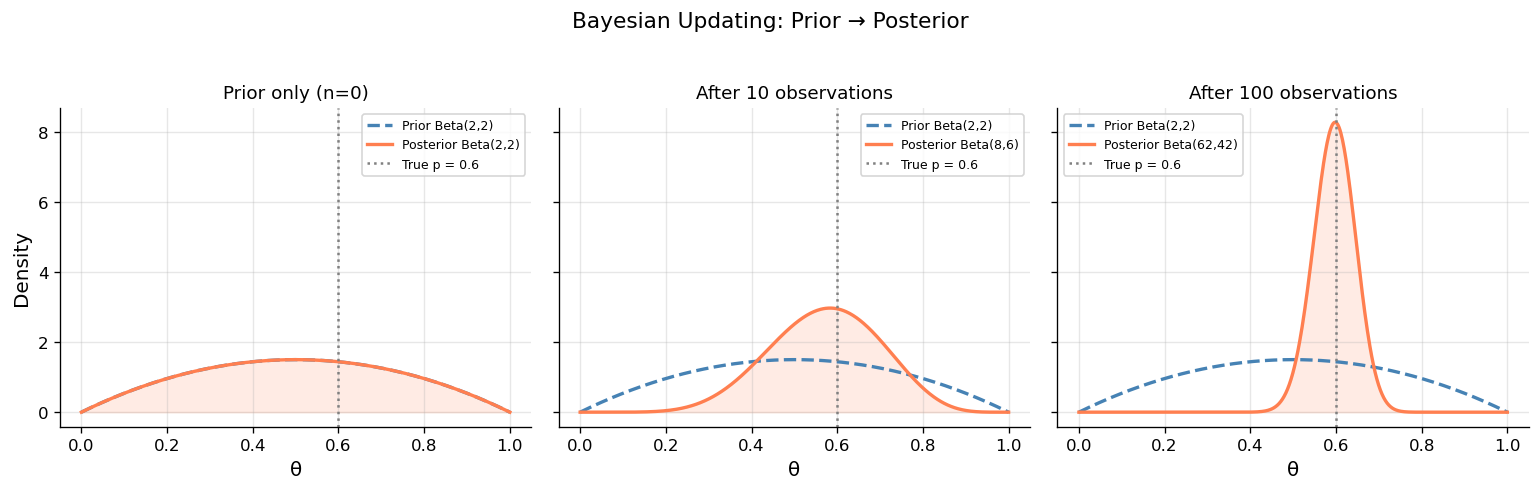

In [ ]:
theta = np.linspace(0, 1, 500)
true_p = 0.6

# Prior: Beta(2, 2) — weakly informative
a_prior, b_prior = 2, 2

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, n_obs, title in zip(
    axes,
    [0, 10, 100],
    ["Prior only (n=0)", "After 10 observations", "After 100 observations"],
):
    # Simulate data
    k = int(true_p * n_obs)  # observed successes
    a_post = a_prior + k
    b_post = b_prior + (n_obs - k)

    ax.plot(
        theta,
        stats.beta.pdf(theta, a_prior, b_prior),
        "steelblue",
        linewidth=2,
        linestyle="--",
        label=f"Prior Beta({a_prior},{b_prior})",
    )
    ax.plot(
        theta,
        stats.beta.pdf(theta, a_post, b_post),
        "coral",
        linewidth=2,
        label=f"Posterior Beta({a_post},{b_post})",
    )
    ax.fill_between(
        theta, stats.beta.pdf(theta, a_post, b_post), alpha=0.15, color="coral"
    )
    ax.axvline(
        true_p, color="gray", linestyle=":", linewidth=1.5, label=f"True p = {true_p}"
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("θ")
    ax.legend(fontsize=7.5)

axes[0].set_ylabel("Density")
plt.suptitle("Bayesian Updating: Prior → Posterior", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 10. Hierarchical (Multilevel) Models

*Module 09.*

**Example:** Students are nested within schools. Each school may have a different baseline performance, but schools are not entirely unrelated — they share a common educational system. A hierarchical model captures both individual school variation and the population-level pattern.

| Term                   | Synonym(s)                                | Definition                                                                                                                                             |
|------------------------|-------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Hierarchical model** | *multilevel model*, *mixed-effects model* | A model with parameters at multiple levels (e.g., individual and group), where group-level parameters are themselves drawn from a shared distribution. |
| **Complete pooling**   | —                                         | Ignore group structure entirely; fit one model to all data. Underestimates group differences.                                                          |
| **No pooling**         | —                                         | Fit a separate model for each group. Overestimates group differences (especially for small groups).                                                    |
| **Partial pooling**    | *shrinkage*                               | Hierarchical compromise: group estimates are pulled ("shrunk") toward the population mean, with small groups shrunk more.                              |
| **Shrinkage**          | —                                         | The tendency of group-level estimates to be pulled toward the overall mean — a key benefit of hierarchical models.                                     |
| **Fixed effect**       | —                                         | A coefficient that is the same for all groups (e.g., the effect of a treatment).                                                                       |
| **Random effect**      | *varying effect*                          | A coefficient that varies across groups (e.g., a school-specific intercept).                                                                           |
| **Random intercept**   | *varying intercept*                       | Each group has its own baseline, drawn from a shared distribution.                                                                                     |
| **Random slope**       | *varying slope*                           | Each group has its own trend, drawn from a shared distribution.                                                                                        |
| **Exchangeability**    | —                                         | Groups are considered interchangeable a priori — we don't know which group is "better" before seeing data. The mathematical basis for partial pooling. |
| **Hyperprior**         | —                                         | A prior on the hyperparameters (e.g., the variance of group-level effects).                                                                            |

---

## 11. Bayesian Regression

*Module 08.*

| Term                                         | Definition                                                                                                                                                             |
|----------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Bayesian linear regression**               | Place priors on regression coefficients $\beta$ and noise variance $\sigma^2$; compute posterior distributions instead of point estimates.                             |
| **Bayesian logistic regression**             | Bayesian version of logistic regression: priors on coefficients, posterior quantifies uncertainty in odds ratios.                                                      |
| **Logistic regression** (syn. *logit model*) | Regression for binary outcomes using the logit link: $\ln\frac{p}{1-p} = \mathbf{X}\beta$.                                                                             |
| **Logit**                                    | $\text{logit}(p) = \ln\frac{p}{1-p}$ — maps probabilities $(0,1)$ to $(-\infty, \infty)$.                                                                              |
| **Odds**                                     | $\frac{p}{1-p}$ — probability of success divided by probability of failure.                                                                                            |
| **Odds ratio**                               | Ratio of odds for two groups: $\text{OR} = \frac{p_1/(1-p_1)}{p_2/(1-p_2)}$. In logistic regression, $e^{\beta_j}$ is the odds ratio for a one-unit increase in $X_j$. |
| **Link function**                            | Function connecting the linear predictor to the mean of the response. Logit for binary, log for counts, identity for Normal.                                           |
| **Generalised linear model (GLM)**           | Extends linear regression to non-Normal responses via a link function and exponential family distributions.                                                            |

---

## 12. Causal Inference

*Module 10.*

---

### Correlation vs. Causation

**Example:** Ice cream sales and drowning rates are correlated. But ice cream doesn't cause drowning — both are caused by hot weather (a *confounder*).

| Term                                       | Definition                                                                                                                        |
|--------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------|
| **Association** (syn. *correlation*)       | Two variables are related — they co-vary. No claim about direction of influence.                                                  |
| **Causation**                              | $X$ directly influences $Y$ — changing $X$ would change $Y$.                                                                      |
| "**Correlation does not imply causation**" | The most important sentence in statistics. An observed association can arise from confounding, reverse causation, or coincidence. |

---

### Directed Acyclic Graphs (DAGs)

| Term                             | Definition                                                                                                                                                 |
|----------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **DAG** (directed acyclic graph) | A diagram with nodes (variables) and directed edges (arrows) representing causal relationships. "Acyclic" means no variable causes itself through a chain. |
| **Causal path**                  | A sequence of arrows from cause to effect, all pointing in the same direction.                                                                             |
| **Backdoor path**                | A non-causal path between $X$ and $Y$ that creates a spurious association (typically through a confounder).                                                |
| **$d$-separation**               | A graphical criterion for determining conditional independence in a DAG.                                                                                   |

---

### Confounding, Mediation, and Colliders

These three patterns are the building blocks of causal reasoning.

| Pattern                                      | Structure                       | What happens if you condition on the middle variable?                                                                                            |
|----------------------------------------------|---------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------|
| **Confounder** (syn. *common cause*, *fork*) | $X \leftarrow Z \rightarrow Y$  | You **should** condition on $Z$ — it blocks the backdoor path and removes spurious association.                                                  |
| **Mediator** (syn. *intermediate variable*)  | $X \rightarrow Z \rightarrow Y$ | Conditioning on $Z$ **blocks** the causal path — don't do it if you want the total effect of $X$ on $Y$.                                         |
| **Collider**                                 | $X \rightarrow Z \leftarrow Y$  | Do **not** condition on $Z$ — doing so *opens* a spurious path between $X$ and $Y$ (**collider bias**, syn. *Berkson's bias*, *selection bias*). |

---

### Causal Effects

| Term                               | Synonym(s)                       | Definition                                                                                                                              |
|------------------------------------|----------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------|
| **Treatment**                      | *exposure*, *intervention*       | The variable whose causal effect we want to estimate.                                                                                   |
| **Outcome**                        | *response*                       | The variable we measure the effect on.                                                                                                  |
| **Potential outcomes**             | *counterfactuals*                | $Y(1)$: outcome if treated; $Y(0)$: outcome if not treated. We observe only one per unit (**fundamental problem of causal inference**). |
| **Average treatment effect (ATE)** | —                                | $E[Y(1) - Y(0)]$ — the average causal effect in the population.                                                                         |
| **Conditional ATE (CATE)**         | *heterogeneous treatment effect* | ATE for a subgroup defined by covariates.                                                                                               |
| **Do-operator**                    | $\text{do}(X = x)$               | Pearl's notation for an *intervention* — forcibly setting $X$ to $x$, removing all arrows into $X$ in the DAG.                          |
| **Interventional distribution**    | $P(Y \mid \text{do}(X = x))$     | Distribution of $Y$ under intervention, distinct from the observational $P(Y \mid X = x)$.                                              |
| **Counterfactual**                 | —                                | "What would have happened if...?" — reasoning about the outcome under an alternative action.                                            |

---

### Causal Identification and Methods

| Term                                  | Definition                                                                                                             |
|---------------------------------------|------------------------------------------------------------------------------------------------------------------------|
| **Identification**                    | Whether a causal effect can be computed from observational data (given the assumed DAG).                               |
| **Backdoor criterion**                | If a set of variables $Z$ blocks all backdoor paths from $X$ to $Y$, conditioning on $Z$ identifies the causal effect. |
| **Adjustment formula**                | $P(Y \mid \text{do}(X)) = \sum_z P(Y \mid X, Z=z)\,P(Z=z)$ — the mathematical expression for the backdoor adjustment.  |
| **Randomised controlled trial (RCT)** | Random assignment eliminates confounding by design — the gold standard for causal inference.                           |
| **Observational study**               | Estimate causal effects without randomisation — requires careful adjustment for confounders.                           |
| **Instrumental variable (IV)**        | A variable that affects treatment but has no direct effect on outcome — used when confounders are unmeasured.          |
| **Propensity score**                  | $P(\text{treated} \mid \text{covariates})$ — used for matching or weighting to create comparable groups.               |

---

## 13. Machine Learning Concepts

*Module 11; also Module 13 (applied ML).*

---

### Regularisation

**Example:** In linear regression with many predictors, OLS may overfit. Adding a penalty on coefficient size constrains the model.

| Term                 | Synonym(s)                                     | Definition                                                                                      |
|----------------------|------------------------------------------------|-------------------------------------------------------------------------------------------------|
| **Regularisation**   | *penalisation*, *shrinkage*                    | Adding a penalty term to the loss function to discourage overly complex models.                 |
| **Ridge regression** | *L2 regularisation*, *Tikhonov regularisation* | Penalty $= \lambda \sum \beta_j^2$. Shrinks coefficients toward zero but doesn't eliminate any. |
| **Lasso** | *L1 regularisation* | Penalty $= \lambda \sum |\beta_j|$. Can shrink coefficients **exactly** to zero — performs variable selection. |
| **Elastic net** | — | Combines L1 and L2 penalties: $\lambda_1 \sum|\beta_j| + \lambda_2 \sum \beta_j^2$. |
| **Regularisation parameter** ($\lambda$) | *penalty strength*, *shrinkage parameter* | Controls the bias-variance tradeoff; chosen by cross-validation. |

---

### Resampling Methods

| Term                                 | Definition                                                                                                     |
|--------------------------------------|----------------------------------------------------------------------------------------------------------------|
| **Bootstrap**                        | Resample **with replacement** from the observed data to estimate the sampling distribution of a statistic.     |
| **Bootstrapped confidence interval** | Confidence interval constructed from the bootstrap distribution (e.g., percentile method).                     |
| **Permutation test**                 | Resample **without replacement** (shuffle labels) to build a null distribution for hypothesis testing.         |
| **$k$-fold cross-validation**        | Split data into $k$ folds; train on $k-1$, test on 1; rotate and average. Estimates out-of-sample performance. |
| **Leave-one-out (LOO)**              | $k$-fold CV with $k = n$ — each observation is the test set once.                                              |
| **Train/test split**                 | Divide data once into training and test sets. Simple but high-variance estimate of performance.                |

---

### Tree-Based Methods

| Term                                       | Definition                                                                                       |
|--------------------------------------------|--------------------------------------------------------------------------------------------------|
| **Decision tree**                          | A model that recursively splits data based on feature values; predictions at leaf nodes.         |
| **Splitting criterion**                    | Rule for choosing the best split (e.g., Gini impurity, information gain, variance reduction).    |
| **Pruning**                                | Removing branches of a tree to reduce overfitting.                                               |
| **Random forest**                          | Ensemble of many decision trees, each trained on a bootstrap sample with random feature subsets. |
| **Bagging** (syn. *bootstrap aggregating*) | Train multiple models on bootstrap samples and average their predictions. Reduces variance.      |
| **Boosting**                               | Sequentially train weak learners, each focusing on the previous learner's errors. Reduces bias.  |
| **Gradient boosting**                      | Boosting where each new model fits the gradient of the loss function (e.g., XGBoost, LightGBM).  |
| **Feature importance**                     | Measure of each feature's contribution to predictions (e.g., mean decrease in impurity).         |

---

### Gaussian Processes

*Module 11 (GP notebook).*

| Term                                    | Definition                                                                                                                               |
|-----------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------|
| **Gaussian process (GP)**               | A non-parametric Bayesian model: any finite collection of points follows a multivariate Normal. Defined by a mean function and a kernel. |
| **Kernel** (syn. *covariance function*) | $k(x, x')$ — measures similarity between inputs; determines the smoothness and structure of the GP.                                      |
| **Length scale**                        | Kernel hyperparameter controlling how quickly the function varies — large length scale = smoother.                                       |
| **Posterior GP**                        | After observing data, the GP posterior gives a distribution over functions — mean prediction plus uncertainty bands.                     |
| **Acquisition function**                | In Bayesian optimisation: a strategy for choosing the next point to evaluate (e.g., expected improvement, UCB).                          |
| **Bayesian optimisation**               | Uses a GP surrogate model and acquisition function to efficiently optimise expensive black-box functions.                                |

---

## 14. Synonym Cross-Reference

The same concept often has multiple names across textbooks, fields, and software documentation. This table collects the most common synonyms encountered in this course.

| Preferred term (this course)       | Common synonyms                                                                  |
|------------------------------------|----------------------------------------------------------------------------------|
| Predictor                          | Independent variable, explanatory variable, covariate, feature, regressor, input |
| Response                           | Dependent variable, outcome, target, output                                      |
| Sample space ($\Omega$)            | Outcome space, possibility space                                                 |
| Probability mass function (PMF)    | Probability function, discrete density                                           |
| Probability density function (PDF) | Density, density function                                                        |
| Expected value                     | Mean, expectation, average, first moment                                         |
| Standard deviation                 | SD, sigma, spread                                                                |
| Variance                           | Var, sigma-squared, second central moment                                        |
| Estimator                          | Statistic (when used for estimation)                                             |
| Maximum likelihood estimator       | MLE                                                                              |
| Confidence interval                | CI, frequentist interval                                                         |
| Credible interval                  | Bayesian confidence interval, posterior interval, Bayesian CI                    |
| HPDI                               | HDI, highest density interval                                                    |
| Null hypothesis ($H_0$)            | Null, baseline hypothesis                                                        |
| p-value                            | Observed significance level, attained significance                               |
| Significance level ($\alpha$)      | Size of the test, Type I error rate                                              |
| Power                              | $1-\beta$, sensitivity (in classification)                                       |
| Type I error                       | False positive, false alarm, $\alpha$ error                                      |
| Type II error                      | False negative, miss, $\beta$ error                                              |
| Sensitivity                        | True positive rate, recall, hit rate, power                                      |
| Specificity                        | True negative rate, selectivity                                                  |
| Prior                              | Prior distribution, prior probability, base rate                                 |
| Posterior                          | Posterior distribution, updated belief                                           |
| Likelihood                         | Likelihood function (when viewed as function of $\theta$)                        |
| Marginal likelihood                | Evidence, model evidence, normalising constant                                   |
| MCMC                               | Markov chain Monte Carlo                                                         |
| Warmup                             | Burn-in                                                                          |
| $\hat{R}$                          | R-hat, Gelman-Rubin statistic, PSRF                                              |
| Hierarchical model                 | Multilevel model, mixed-effects model                                            |
| Random effect                      | Varying effect                                                                   |
| Partial pooling                    | Shrinkage (in hierarchical context)                                              |
| Confounder                         | Common cause, lurking variable, fork (in DAG terminology)                        |
| Collider bias                      | Berkson's bias, selection bias, conditioning-on-collider bias                    |
| Treatment                          | Exposure, intervention                                                           |
| ATE                                | Average treatment effect, average causal effect                                  |
| Do-operator                        | Intervention operator                                                            |
| Regularisation                     | Penalisation, shrinkage                                                          |
| Ridge                              | L2 regularisation, Tikhonov regularisation, weight decay                         |
| Lasso                              | L1 regularisation                                                                |
| Bagging                            | Bootstrap aggregating                                                            |
| Kernel (GP)                        | Covariance function                                                              |
| OLS                                | Ordinary least squares, least-squares regression                                 |
| $R^2$                              | R-squared, coefficient of determination                                          |
| Residual                           | Error (in some textbooks), deviation from fit                                    |
| Degrees of freedom                 | df, $\nu$, $k$ (context-dependent)                                               |
| Homoscedasticity                   | Constant variance, equal variance                                                |
| Heteroscedasticity                 | Non-constant variance, unequal variance                                          |

---

## Further Reading

| Topic                                   | Resource                                                                                                                                 |
|-----------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------|
| Probability & statistics (introductory) | [Khan Academy — Statistics and Probability](https://www.khanacademy.org/math/statistics-probability)                                     |
| Statistical inference                   | Casella & Berger, *Statistical Inference* (2nd ed.)                                                                                      |
| Bayesian statistics                     | McElreath, *Statistical Rethinking* (2nd ed.); [free lectures](https://www.youtube.com/playlist?list=PLDcUM9US4XdPz-KxHM4XHt7uUVGWWVSus) |
| Causal inference                        | Pearl, Glymour & Jewell, *Causal Inference in Statistics: A Primer*                                                                      |
| Machine learning                        | Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning* ([free PDF](https://hastie.su.domains/ElemStatLearn/))             |
| Visual explanations                     | [Seeing Theory](https://seeing-theory.brown.edu/) — interactive visualisations of probability and statistics                             |

**Next:** [Module 01 — Probability Basics](../01_probability_basics/01_sample_spaces.ipynb) — where we begin using these terms in earnest.